## Test ensemble LB

### ToDo
- split model run and analysis
- automate in .py?
- fix links to forcing and shapefiles etc
- auto delete files

In [52]:
# General python
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

from pathlib import Path

# General eWaterCycle
import ewatercycle
import ewatercycle.forcing
import ewatercycle.models
import fiona
import matplotlib.pyplot as plt
import numpy as np
import shapely.geometry
import xarray as xr
from ewatercycle_leakybucket.model import LeakyBucket
from pyproj import Geod

# Niceties
from rich import print
from tqdm.notebook import tqdm

In [ ]:
# The name of the shapefile
shape_file_name = "GRDC_Kerki"  # river: Bedford Ouse at Roxton, England

# The time-window of the experiment
experiment_start_date = "1990-01-01T00:00:00Z"
experiment_end_date = "1995-12-31T00:00:00Z"

forcing_path_ERA5 = (
    Path.home()
    / "MSc_AralSea"
    / "book"
    / "thesis_projects"
    / "MSc"
    / "2025_Q1_AndreVanDerVeen_CEG"
    / "work_in_progress"
    / "forcing"
    / "output"
    / "forcing_HBV_ERA5_GRDC_Kerki_5456"
    / shape_file_name
    / "ERA5"
    / "own_shapefile"
)


load_location = forcing_path_ERA5 / "work" / "diagnostic" / "script"
ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=load_location)

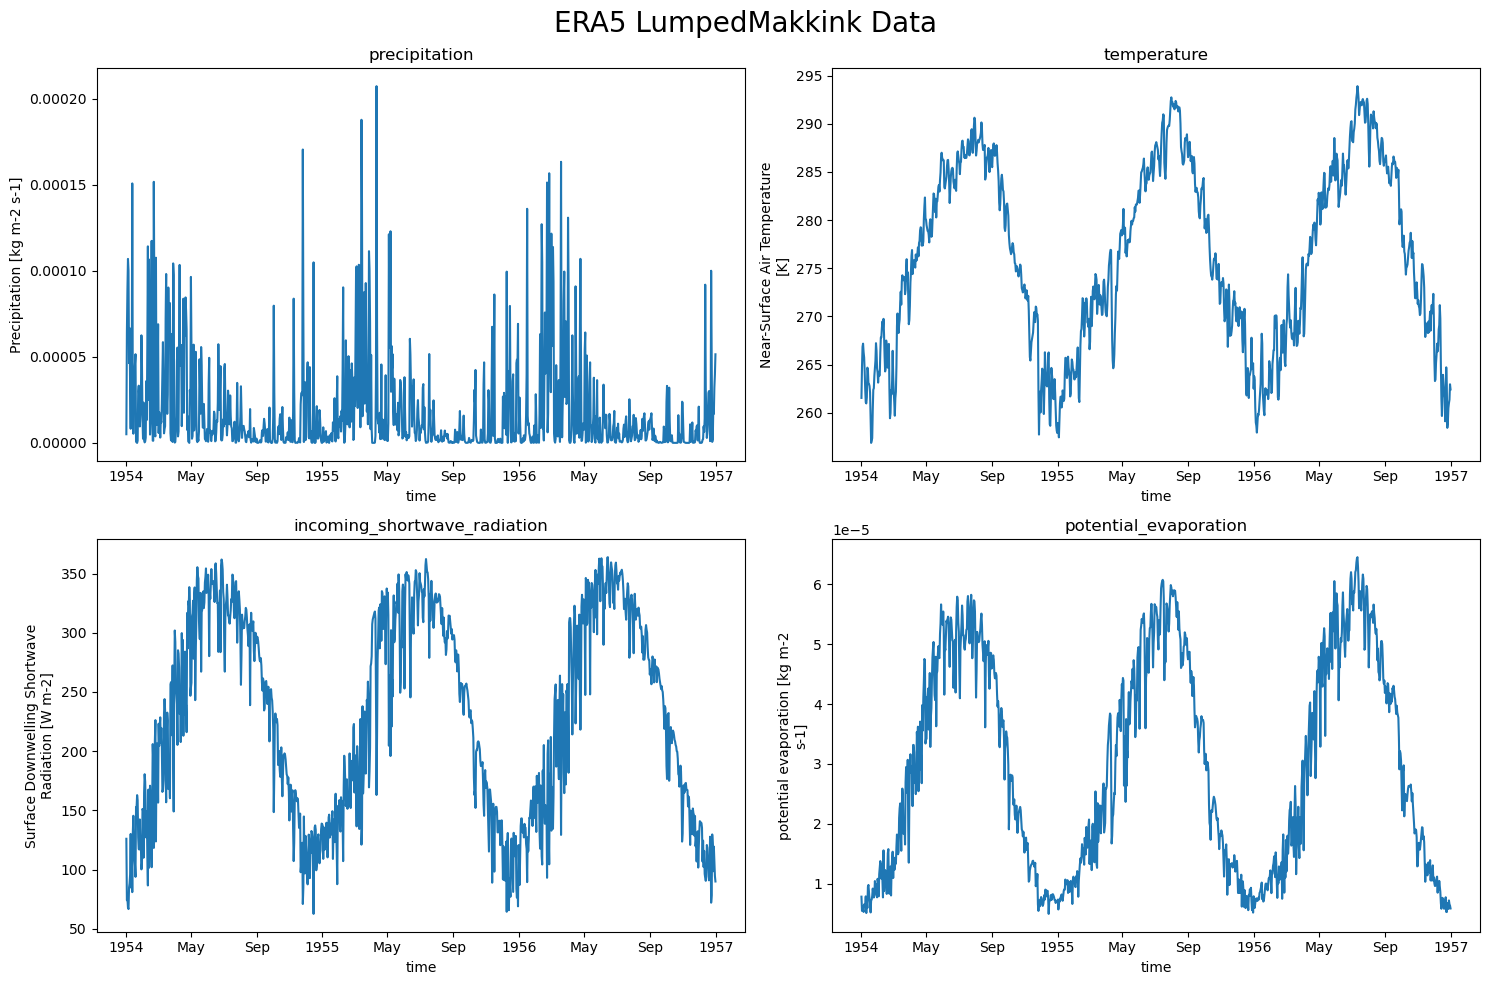

In [54]:
ERA5_data = {
    "precipitation pr": xr.open_dataset(ERA5_forcing["pr"]),
    "temperature tas": xr.open_dataset(ERA5_forcing["tas"]),
    "incoming_shortwave_radiation rsds": xr.open_dataset(ERA5_forcing["rsds"]),
    "potential_evaporation evspsblpot": xr.open_dataset(ERA5_forcing["evspsblpot"]),
}

plot_counter = 1
plt.figure(figsize=(15, 10))
for name, data in ERA5_data.items():
    plt.subplot(2, 2, plot_counter)
    data[name.split(" ")[-1]].plot()
    plt.title(f"{name.split(" ")[0]}")
    plot_counter += 1

plt.suptitle("ERA5 LumpedMakkink Data", fontsize=20)
plt.tight_layout()

In [55]:
# number of experiments
n_experiments = 49

# select even spaced values for leakiness
leakiness_values = np.linspace(0.0, 0.2, n_experiments + 2)
leakiness_values = leakiness_values[1:-1]
print(leakiness_values)

[0.004 0.008 0.012 0.016 0.02  0.024 0.028 0.032 0.036 0.04  0.044 0.048
 0.052 0.056 0.06  0.064 0.068 0.072 0.076 0.08  0.084 0.088 0.092 0.096
 0.1   0.104 0.108 0.112 0.116 0.12  0.124 0.128 0.132 0.136 0.14  0.144
 0.148 0.152 0.156 0.16  0.164 0.168 0.172 0.176 0.18  0.184 0.188 0.192
 0.196]

In [ ]:
all_discharges = []

for leak in tqdm(leakiness_values, desc="Running LeakyBucket experiments"):
    model = LeakyBucket(forcing=ERA5_forcing)

    cfg_file, _ = model.setup(leakiness=leak)
    model.initialize(cfg_file)

    discharges = []
    while model.time < model.end_time:
        discharges.append(model.get_value_as_xarray("discharge"))
        model.update()

    discharge = xr.concat(discharges, dim="time")

    # Add leakiness as coordinate
    discharge = discharge.assign_coords(leakiness=leak).expand_dims("leakiness")

    all_discharges.append(discharge)

    # Clean up model
    model.finalize()

Running LeakyBucket experiments:   0%|          | 0/49 [00:00<?, ?it/s]

In [57]:
discharge_all = xr.concat(all_discharges, dim="leakiness")

In [82]:
from ewatercycle.observation.grdc import get_grdc_data

ds = get_grdc_data(
    2617110,
    "1954-01-01T00:00Z",
    "1956-12-31T00:00Z",
    data_home="/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/",
)

ds

<xarray.Dataset> Size: 18kB
Dimensions:              (time: 1096)
Coordinates:
  * time                 (time) datetime64[ns] 9kB 1954-01-01 ... 1956-12-31
    id                   int64 8B 2617110
Data variables:
    streamflow           (time) float64 9kB 1.3e+03 1.26e+03 ... 722.0 678.0
    area                 float64 8B 3.09e+05
    country              <U2 8B 'TM'
    geo_x                float64 8B 65.25
    geo_y                float64 8B 37.83
    geo_z                float64 8B 241.0
    owneroforiginaldata  <U85 340B 'Initial dataset collected in the framewor...
    river_name           <U9 36B 'AMU DARYA'
    station_name         <U5 20B 'KERKI'
    timezone             float64 8B nan
Attributes:
    title:          NA
    Conventions:    CF-1.7
    references:     grdc.bafg.de
    institution:    GRDC
    history:        Converted from 2617110_Q_Day.Cmd.txt of 2025-09-02 to net...
    missing_value:  -999.000

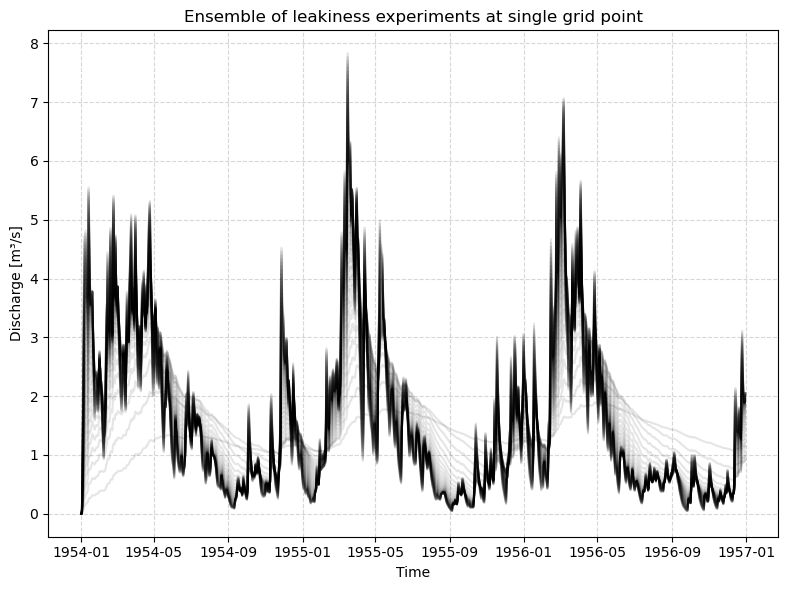

In [ ]:
discharge_point = discharge_all.isel(latitude=0, longitude=0)

discharge_1955 = discharge_point.sel(time=slice("1954-01-01", "1956-12-31"))


plt.figure(figsize=(8, 6))

for i, leak in enumerate(discharge_1955.leakiness.values):
    plt.plot(
        discharge_1955.time,
        discharge_1955.isel(leakiness=i),
        label=f"leakiness={leak:.2f}",
        color="black",
        alpha=0.1,
    )

plt.xlabel("Time")
plt.ylabel("Discharge [m³/s]")
plt.title("Ensemble of LeakyBucket experiments")
# plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [84]:
def catchment_area_from_shapefile(shapefile_path, ellps="WGS84"):
    """
    Compute the area (in m²) of the first polygon in a shapefile.

    Parameters
    ----------
    shapefile_path : str
        Path to the shapefile (.shp)
    ellps : str, optional
        Ellipsoid for area calculation (default: WGS84)

    Returns
    -------
    float
        Absolute area of the polygon in square meters
    """
    # Load polygon
    with fiona.open(shapefile_path) as src:
        poly = shapely.geometry.shape(src[0]["geometry"])

    # Define ellipsoid
    geod = Geod(ellps=ellps)

    # Compute area and perimeter
    area, _ = geod.geometry_area_perimeter(poly)

    return abs(area)

In [85]:
area_Kerki = catchment_area_from_shapefile(
    "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/AralSea_Basin/GRDC_Kerki/GRDC_Kerki.shp"
)
conversion_mmday2m3s = 1 / (1000 * 86400)

conversion_factor = conversion_mmday2m3s * area_Kerki

In [86]:
discharge_m3s = discharge_all * conversion_factor

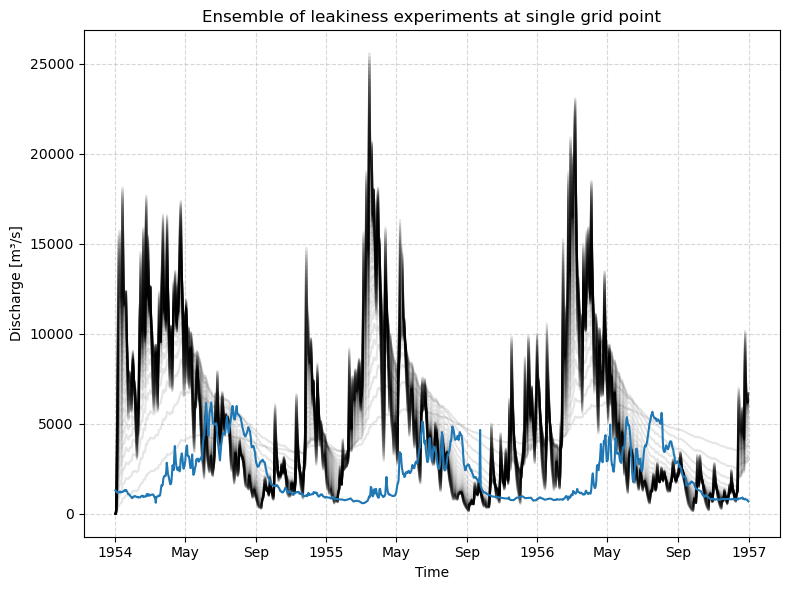

In [ ]:
discharge_point_m3 = discharge_m3s.isel(latitude=0, longitude=0)

discharge_1955_m3 = discharge_point_m3.sel(time=slice("1954-01-01", "1956-12-31"))

discharge_selection = discharge_1955_m3.sel(leakiness=slice(0, 1))

plt.figure(figsize=(8, 6))

for i, leak in enumerate(discharge_selection.leakiness.values):
    plt.plot(
        discharge_selection.time,
        discharge_selection.isel(leakiness=i),
        label=f"leakiness={leak:.2f}",
        color="black",
        alpha=0.1,
    )


# plot GRDC
max_y = 2 * ds["streamflow"].max()
ds["streamflow"].plot()

plt.xlabel("Time")
plt.ylabel("Discharge [m³/s]")
plt.title("Ensemble of LeakyBucket experiments")
# plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
# plt.ylim(0,max_y)
plt.show()

In [91]:
discharge_all.to_netcdf("discharge_all_leakiness.nc")
discharge_m3s.to_netcdf("discharge_m3s_leakiness.nc")